In [1]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [7]:
matches = pd.read_csv(
    r"C:\Users\Teju\OneDrive\Desktop\Project\IPL-Player-Stats-EDA\data\IPL dataset\matches.csv"
)

In [8]:

deliveries = pd.read_csv(
    r"C:\Users\Teju\OneDrive\Desktop\Project\IPL-Player-Stats-EDA\data\IPL dataset\deliveries.csv"
)

In [9]:
print(matches.shape)
print(deliveries.shape)

(636, 18)
(150460, 21)


In [10]:
print(matches.columns)
print(deliveries.columns)

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='str')
Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')


In [11]:
print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
matches.head()

Matches shape: (636, 18)
Deliveries shape: (150460, 21)


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [12]:
matches.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

In [13]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [14]:
print(matches['season'].unique())
print("Total seasons:", matches['season'].nunique())

[2017 2008 2009 2010 2011 2012 2013 2014 2015 2016]
Total seasons: 10


In [15]:
batsman_runs = deliveries.groupby('batsman')['batsman_runs'].sum()

In [16]:
top10 = batsman_runs.sort_values(ascending=False).head(10)

In [17]:
print(top10)


batsman
SK Raina          4548
V Kohli           4423
RG Sharma         4207
G Gambhir         4132
DA Warner         4014
RV Uthappa        3778
CH Gayle          3651
S Dhawan          3561
MS Dhoni          3560
AB de Villiers    3486
Name: batsman_runs, dtype: int64


C:\Users\Teju\AppData\Local\Temp\ipykernel_12484\539460685.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='viridis')


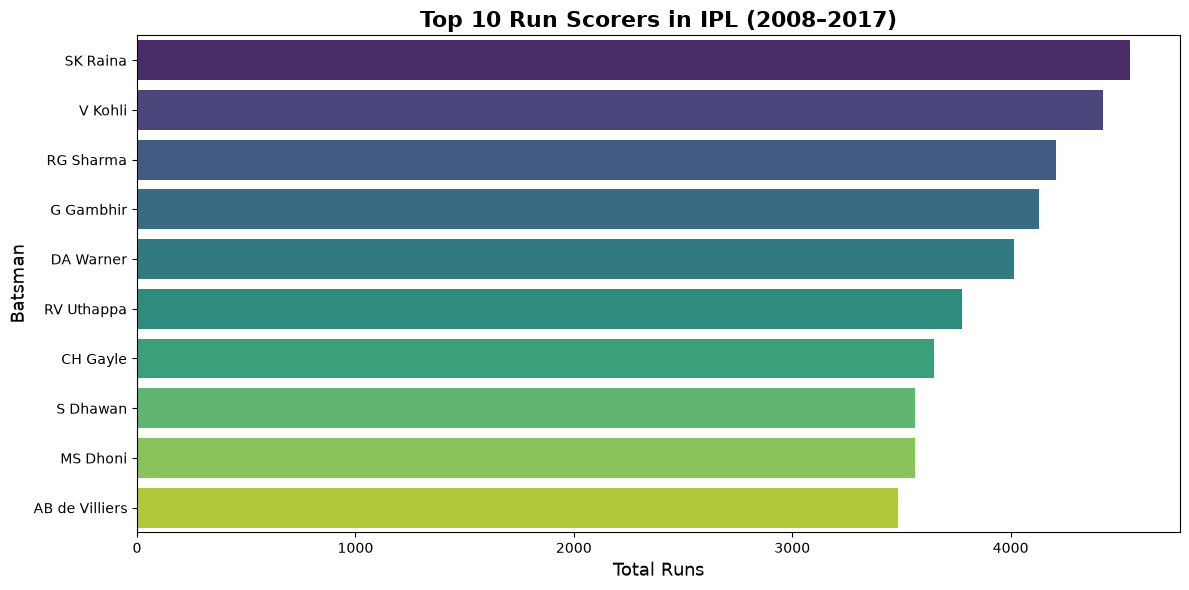

In [18]:
plt.figure(figsize=(12, 6))

sns.barplot(x=top10.values, y=top10.index, palette='viridis')

plt.title('Top 10 Run Scorers in IPL (2008–2017)', fontsize=16, fontweight='bold')
plt.xlabel('Total Runs', fontsize=13)
plt.ylabel('Batsman', fontsize=13)

plt.tight_layout()
plt.show()

In [19]:
runs = deliveries.groupby('batsman')['batsman_runs'].sum()

In [42]:
matches_clean = matches[matches['winner'].notna()].copy()

venue_mapping = {
    'M Chinnaswamy Stadium': 'Chinnaswamy',
    'Wankhede Stadium': 'Wankhede',
    'Eden Gardens': 'Eden Gardens',
    'Feroz Shah Kotla': 'Feroz Shah Kotla',
    'MA Chidambaram Stadium': 'Chidambaram',
    'Rajiv Gandhi International Stadium': 'Rajiv Gandhi',
    'Punjab Cricket Association Stadium': 'PCA Stadium',
    'Punjab Cricket Association IS Bindra Stadium': 'PCA Stadium',
    'Sawai Mansingh Stadium': 'Sawai Mansingh',
    'Subrata Roy Sahara Stadium': 'Sahara Stadium',
    'DY Patil Sports Academy': 'DY Patil',
    'Brabourne Stadium': 'Brabourne'
}

def clean_venue(venue):
    for key in venue_mapping:
        if key in venue:
            return venue_mapping[key]
    return venue.split(',')[0].strip()

matches_clean['venue_short'] = matches_clean['venue'].apply(clean_venue)
print(matches_clean['venue_short'].value_counts().head(10))

venue_short
Chinnaswamy         64
Eden Gardens        61
Feroz Shah Kotla    59
Wankhede            57
Rajiv Gandhi        49
Chidambaram         48
PCA Stadium         46
Sawai Mansingh      33
DY Patil            17
Sahara Stadium      17
Name: count, dtype: int64


In [45]:
# Count total matches played at each venue by each team
# A team plays as either team1 or team2, so we check both

match_list = []

for _, row in matches_clean.iterrows():
    match_list.append({'venue': row['venue_short'], 'team': row['team1']})
    match_list.append({'venue': row['venue_short'], 'team': row['team2']})

all_matches = pd.DataFrame(match_list)
total_matches = all_matches.groupby(['venue', 'team']).size()

# Count wins
win_list = []
for _, row in matches_clean.iterrows():
    win_list.append({'venue': row['venue_short'], 'team': row['winner']})

all_wins = pd.DataFrame(win_list)
total_wins = all_wins.groupby(['venue', 'team']).size()

# Calculate win percentage
win_pct_series = (total_wins / total_matches * 100).fillna(0).round(0)

# Build grid
win_pct_grid = win_pct_series.unstack(level='team').fillna(0)

print("Max value in grid:", win_pct_grid.max().max())
print(win_pct_grid.shape)

Max value in grid: 100.0
(34, 14)


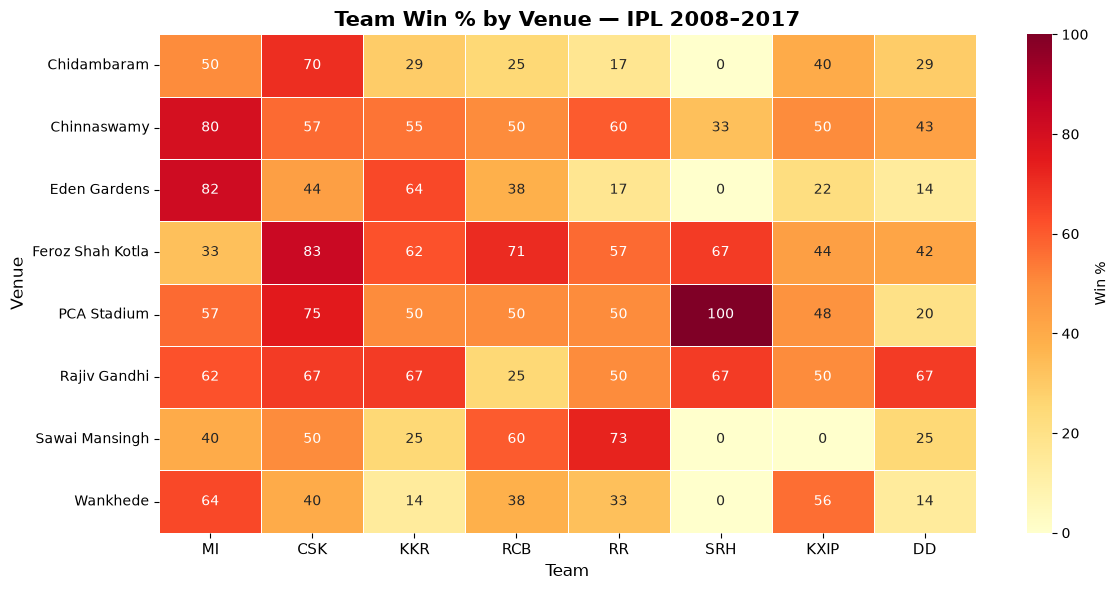

In [46]:
top_venues = matches_clean['venue_short'].value_counts().head(8).index.tolist()
top_teams = ['Mumbai Indians', 'Chennai Super Kings', 'Kolkata Knight Riders',
             'Royal Challengers Bangalore', 'Rajasthan Royals',
             'Sunrisers Hyderabad', 'Kings XI Punjab', 'Delhi Daredevils']

win_pct_filtered = win_pct_grid.loc[
    win_pct_grid.index.isin(top_venues),
    [t for t in top_teams if t in win_pct_grid.columns]
]

team_short = {
    'Mumbai Indians': 'MI',
    'Chennai Super Kings': 'CSK',
    'Kolkata Knight Riders': 'KKR',
    'Royal Challengers Bangalore': 'RCB',
    'Rajasthan Royals': 'RR',
    'Sunrisers Hyderabad': 'SRH',
    'Kings XI Punjab': 'KXIP',
    'Delhi Daredevils': 'DD'
}
win_pct_filtered.columns = [team_short.get(c, c) for c in win_pct_filtered.columns]

plt.figure(figsize=(12, 6))
sns.heatmap(
    win_pct_filtered,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    vmin=0,
    vmax=100,
    cbar_kws={'label': 'Win %'}
)
plt.title('Team Win % by Venue — IPL 2008–2017', fontsize=15, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [20]:
balls = deliveries.groupby('batsman')['ball'].count()

In [21]:
dismissals = deliveries[deliveries['player_dismissed'].notna()].groupby('player_dismissed')['player_dismissed'].count()

In [22]:
batting_stats = pd.DataFrame({
    'runs': runs,
    'balls': balls,
    'dismissals': dismissals
}).dropna()

In [23]:
batting_stats['average'] = batting_stats['runs'] / batting_stats['dismissals']
batting_stats['strike_rate'] = (batting_stats['runs'] / batting_stats['balls']) * 100

In [24]:
qualified = batting_stats[batting_stats['balls'] >= 500]

In [25]:
print(f"Total qualified batsmen: {len(qualified)}")
print(qualified[['runs', 'average', 'strike_rate']].sort_values('runs', ascending=False).head(10))

Total qualified batsmen: 78
                  runs    average  strike_rate
SK Raina        4548.0  33.940299   134.995548
V Kohli         4423.0  37.483051   126.588437
RG Sharma       4207.0  32.612403   128.497251
G Gambhir       4132.0  31.541985   120.361200
DA Warner       4014.0  40.140000   138.318401
RV Uthappa      3778.0  29.515625   127.635135
CH Gayle        3651.0  41.022472   144.194313
S Dhawan        3561.0  32.669725   118.502496
MS Dhoni        3560.0  37.872340   132.835821
AB de Villiers  3486.0  38.307692   145.129059


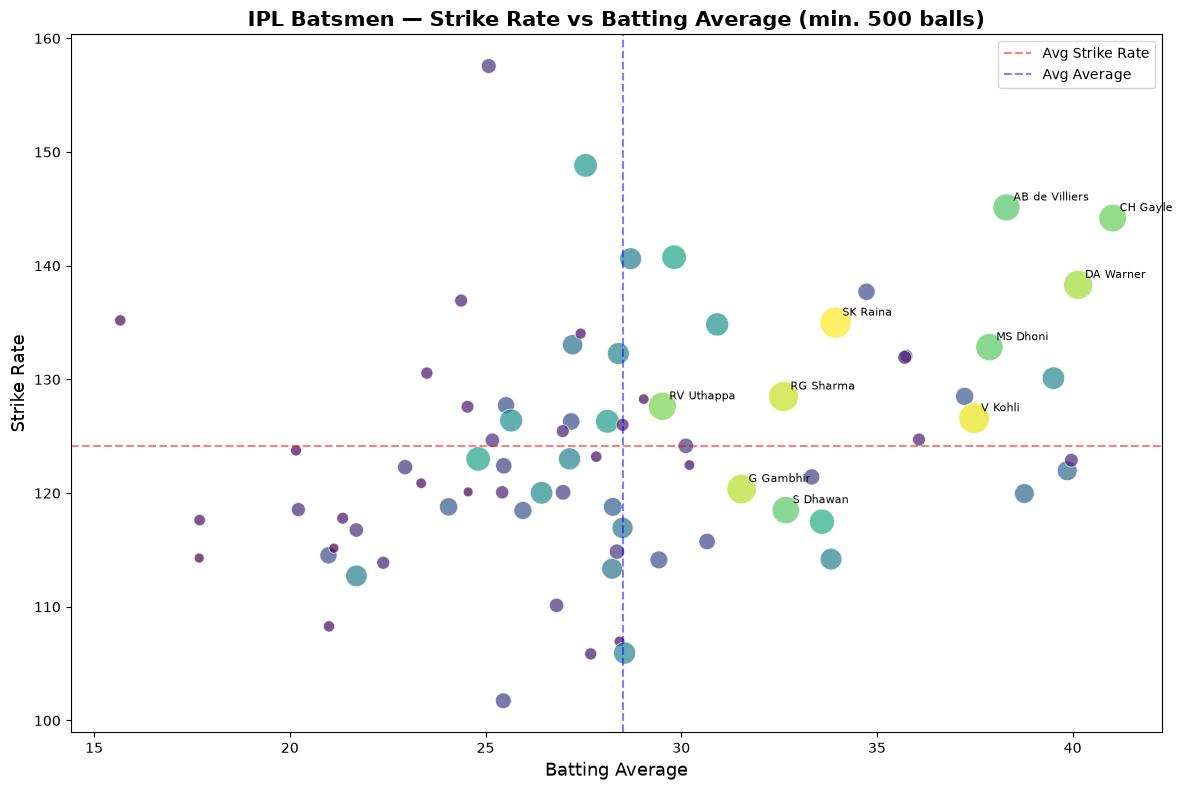

In [47]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=qualified,
    x='average',
    y='strike_rate',
    size='runs',
    hue='runs',
    palette='viridis',
    sizes=(50, 500),
    alpha=0.7,
    legend=False
)

# Label the top players
top_players = qualified.nlargest(10, 'runs')
for _, row in top_players.iterrows():
    plt.annotate(
        row.name,
        xy=(row['average'], row['strike_rate']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.title('IPL Batsmen — Strike Rate vs Batting Average (min. 500 balls)', fontsize=15, fontweight='bold')
plt.xlabel('Batting Average', fontsize=13)
plt.ylabel('Strike Rate', fontsize=13)
plt.axhline(y=qualified['strike_rate'].mean(), color='red', linestyle='--', alpha=0.5, label='Avg Strike Rate')
plt.axvline(x=qualified['average'].mean(), color='blue', linestyle='--', alpha=0.5, label='Avg Average')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
mystery = qualified[qualified['strike_rate'] > 150]
print(mystery[['runs', 'balls', 'average', 'strike_rate']])

              runs  balls    average  strike_rate
GJ Maxwell  1229.0  780.0  25.081633   157.564103


In [28]:
matches_clean = matches[matches['winner'].notna()]

In [29]:
matches_clean = matches_clean.copy()
matches_clean['venue_short'] = matches_clean['venue'].str.split(',').str[0]

In [30]:
total_matches = matches_clean.groupby(['venue_short', 'team1']).size() + \
                matches_clean.groupby(['venue_short', 'team2']).size()
total_matches = total_matches.fillna(0)

In [31]:
wins = matches_clean.groupby(['venue_short', 'winner']).size()

In [32]:
win_pct = (wins / total_matches * 100).fillna(0)
win_pct = win_pct.unstack(level=1).fillna(0)

In [33]:
top_venues = matches_clean['venue_short'].value_counts().head(10).index
top_teams = matches_clean['team1'].value_counts().head(8).index

win_pct_filtered = win_pct.loc[top_venues, top_teams]

In [35]:
 print(matches_clean['venue_short'].value_counts().head(15))

venue_short
M Chinnaswamy Stadium                           64
Eden Gardens                                    61
Feroz Shah Kotla                                59
Wankhede Stadium                                57
Rajiv Gandhi International Stadium              49
MA Chidambaram Stadium                          48
Punjab Cricket Association Stadium              35
Sawai Mansingh Stadium                          33
Dr DY Patil Sports Academy                      17
Subrata Roy Sahara Stadium                      17
Maharashtra Cricket Association Stadium         15
Kingsmead                                       15
SuperSport Park                                 12
Sardar Patel Stadium                            12
Punjab Cricket Association IS Bindra Stadium    11
Name: count, dtype: int64


In [36]:
matches_clean = matches[matches['winner'].notna()].copy()

venue_mapping = {
    'M Chinnaswamy Stadium': 'Chinnaswamy',
    'Wankhede Stadium': 'Wankhede',
    'Eden Gardens': 'Eden Gardens',
    'Feroz Shah Kotla': 'Feroz Shah Kotla',
    'MA Chidambaram Stadium': 'Chidambaram',
    'Rajiv Gandhi International Stadium': 'Rajiv Gandhi',
    'Punjab Cricket Association Stadium': 'PCA Stadium',
    'Punjab Cricket Association IS Bindra Stadium': 'PCA Stadium',
    'Sawai Mansingh Stadium': 'Sawai Mansingh',
    'Subrata Roy Sahara Stadium': 'Sahara Stadium',
    'DY Patil Sports Academy': 'DY Patil',
    'Brabourne Stadium': 'Brabourne'
}

def clean_venue(venue):
    for key in venue_mapping:
        if key in venue:
            return venue_mapping[key]
    return venue.split(',')[0].strip()

matches_clean['venue_short'] = matches_clean['venue'].apply(clean_venue)

In [38]:
matches_clean = matches[matches['winner'].notna()].copy()

venue_mapping = {
    'M Chinnaswamy Stadium': 'Chinnaswamy',
    'Wankhede Stadium': 'Wankhede',
    'Eden Gardens': 'Eden Gardens',
    'Feroz Shah Kotla': 'Feroz Shah Kotla',
    'MA Chidambaram Stadium': 'Chidambaram',
    'Rajiv Gandhi International Stadium': 'Rajiv Gandhi',
    'Punjab Cricket Association Stadium': 'PCA Stadium',
    'Punjab Cricket Association IS Bindra Stadium': 'PCA Stadium',
    'Sawai Mansingh Stadium': 'Sawai Mansingh',
    'Subrata Roy Sahara Stadium': 'Sahara Stadium',
    'DY Patil Sports Academy': 'DY Patil',
    'Brabourne Stadium': 'Brabourne'
}

def clean_venue(venue):
    for key in venue_mapping:
        if key in venue:
            return venue_mapping[key]
    return venue.split(',')[0].strip()

matches_clean['venue_short'] = matches_clean['venue'].apply(clean_venue)

print(matches_clean['venue_short'].value_counts().head(10))

venue_short
Chinnaswamy         64
Eden Gardens        61
Feroz Shah Kotla    59
Wankhede            57
Rajiv Gandhi        49
Chidambaram         48
PCA Stadium         46
Sawai Mansingh      33
DY Patil            17
Sahara Stadium      17
Name: count, dtype: int64


In [39]:
total_matches = matches_clean.groupby(['venue_short', 'team1']).size() + \
                matches_clean.groupby(['venue_short', 'team2']).size()
total_matches = total_matches.fillna(0)

wins = matches_clean.groupby(['venue_short', 'winner']).size()

In [40]:
win_pct = (wins / total_matches * 100).fillna(0)
win_pct = win_pct.unstack(level=1).fillna(0)

C:\Users\Teju\AppData\Local\Temp\ipykernel_12484\539460685.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='viridis')


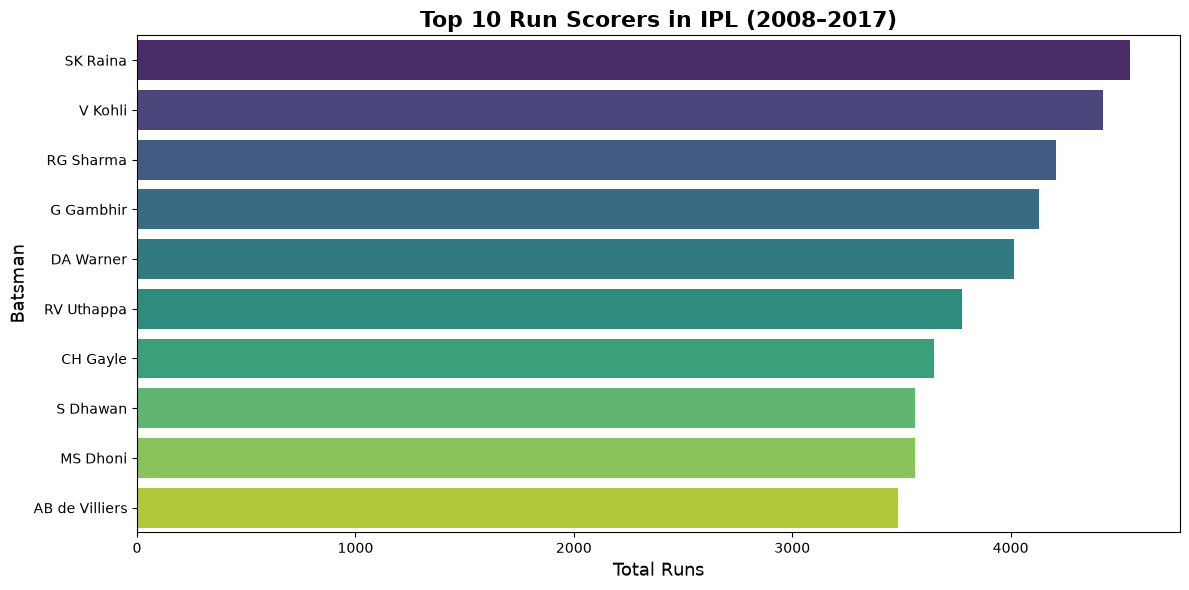

In [18]:
plt.figure(figsize=(12, 6))

sns.barplot(x=top10.values, y=top10.index, palette='viridis')

plt.title('Top 10 Run Scorers in IPL (2008–2017)', fontsize=16, fontweight='bold')
plt.xlabel('Total Runs', fontsize=13)
plt.ylabel('Batsman', fontsize=13)

plt.tight_layout()
plt.show()

In [48]:
death_overs = deliveries[deliveries['over'] >= 17]
print(f"Total death over deliveries: {len(death_overs)}")
print(death_overs['over'].unique())


Total death over deliveries: 26405
[17 18 19 20]


In [49]:
death_runs = death_overs.groupby('bowler')['total_runs'].sum()
death_balls = death_overs.groupby('bowler')['ball'].count()
death_overs_bowled = death_balls / 6

economy = (death_runs / death_overs_bowled).round(2)
economy = economy[death_balls >= 60].sort_values()

print(f"Qualified bowlers (60+ balls): {len(economy)}")
print(economy.head(10))

Qualified bowlers (60+ balls): 107
bowler
Sohail Tanvir        6.73
DE Bollinger         7.44
SP Narine            7.44
SL Malinga           7.57
BA Stokes            7.75
WD Parnell           7.76
MA Starc             7.82
A Kumble             7.93
Mustafizur Rahman    7.93
Harbhajan Singh      8.09
dtype: float64


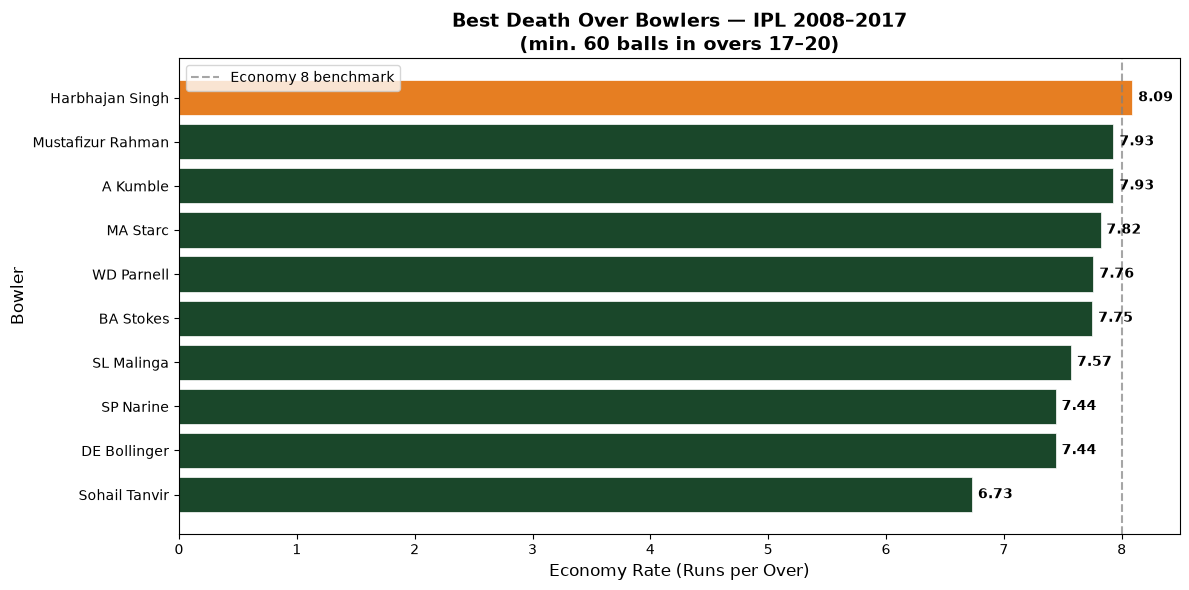

In [50]:
top_death = economy.head(10)

plt.figure(figsize=(12, 6))

colors = ['#1a472a' if x < 8 else '#e67e22' if x < 9 else '#c0392b' 
          for x in top_death.values]

bars = plt.barh(top_death.index, top_death.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top_death.values):
    plt.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=10, fontweight='bold')

plt.axvline(x=8, color='gray', linestyle='--', alpha=0.7, label='Economy 8 benchmark')
plt.title('Best Death Over Bowlers — IPL 2008–2017\n(min. 60 balls in overs 17–20)',
          fontsize=14, fontweight='bold')
plt.xlabel('Economy Rate (Runs per Over)', fontsize=12)
plt.ylabel('Bowler', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [51]:
print(matches_clean['toss_decision'].value_counts())
print()
print(matches_clean['toss_winner'].value_counts().head(5))

toss_decision
field    361
bat      272
Name: count, dtype: int64

toss_winner
Mumbai Indians                 85
Kolkata Knight Riders          78
Delhi Daredevils               71
Royal Challengers Bangalore    69
Kings XI Punjab                68
Name: count, dtype: int64


In [52]:
matches_clean['toss_winner_won'] = matches_clean['toss_winner'] == matches_clean['winner']

toss_win_counts = matches_clean['toss_winner_won'].value_counts()
toss_win_pct = (matches_clean['toss_winner_won'].sum() / len(matches_clean) * 100).round(1)

print(f"Times toss winner won the match: {matches_clean['toss_winner_won'].sum()}")
print(f"Times toss winner lost the match: {(~matches_clean['toss_winner_won']).sum()}")
print(f"Toss winner wins: {toss_win_pct}% of the time")

Times toss winner won the match: 325
Times toss winner lost the match: 308
Toss winner wins: 51.3% of the time


In [53]:
bat_first = matches_clean[matches_clean['toss_decision'] == 'bat']
field_first = matches_clean[matches_clean['toss_decision'] == 'field']

bat_win_pct = (bat_first['toss_winner_won'].sum() / len(bat_first) * 100).round(1)
field_win_pct = (field_first['toss_winner_won'].sum() / len(field_first) * 100).round(1)

print(f"Chose to BAT — won {bat_win_pct}% of matches")
print(f"Chose to FIELD — won {field_win_pct}% of matches")

Chose to BAT — won 45.6% of matches
Chose to FIELD — won 55.7% of matches


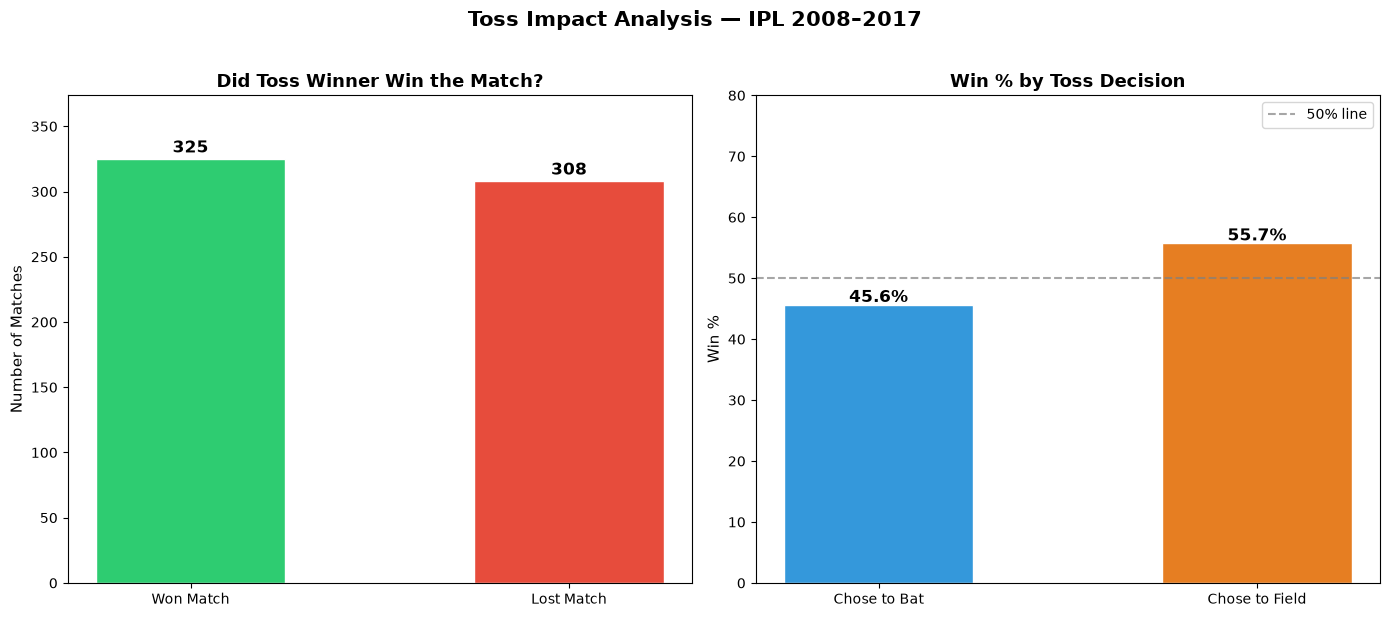

In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left chart: Did toss winner win? ---
labels1 = ['Won Match', 'Lost Match']
values1 = [matches_clean['toss_winner_won'].sum(),
           (~matches_clean['toss_winner_won']).sum()]
colors1 = ['#2ecc71', '#e74c3c']

bars1 = ax1.bar(labels1, values1, color=colors1, width=0.5, edgecolor='white')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(int(bar.get_height())),
             ha='center', fontsize=12, fontweight='bold')

ax1.set_title('Did Toss Winner Win the Match?', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Matches', fontsize=11)
ax1.set_ylim(0, max(values1) * 1.15)

# --- Right chart: Bat vs Field win % ---
labels2 = ['Chose to Bat', 'Chose to Field']
values2 = [bat_win_pct, field_win_pct]
colors2 = ['#3498db', '#e67e22']

bars2 = ax2.bar(labels2, values2, color=colors2, width=0.5, edgecolor='white')

for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{bar.get_height()}%',
             ha='center', fontsize=12, fontweight='bold')

ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label='50% line')
ax2.set_title('Win % by Toss Decision', fontsize=13, fontweight='bold')
ax2.set_ylabel('Win %', fontsize=11)
ax2.set_ylim(0, 80)
ax2.legend(fontsize=10)

fig.suptitle('Toss Impact Analysis — IPL 2008–2017',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()